In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from sklearn.metrics import accuracy_score, precision_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
df = pd.read_csv('bank_personal_loan_data.csv')
print(df.shape)
df.head()

(5000, 14)


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan
0,1,25,1,49,91107,4,1.6,1,0,1,0,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,1,0,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,1,0


In [4]:
df.dtypes

ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIP Code                int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
Personal Loan           int64
dtype: object

In [5]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.104400,0.06040,0.596800,0.294000,0.096000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.305809,0.23825,0.490589,0.455637,0.294621
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.00000,1.000000,1.000000,0.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.00000,1.000000,1.000000,1.000000


In [6]:
print(df.isnull().sum())

negative_experience_count = (df['Experience'] < 0).sum()

print("Rows with negative Experience:", negative_experience_count)

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
Personal Loan         0
dtype: int64
Rows with negative Experience: 52


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
cols = ["Education", "Securities Account", "CD Account", "Online", "CreditCard", "Personal Loan"]

for col in cols:
    print(col, ":", sorted(df[col].unique()))

cols_dftest = df.drop(columns=cols).columns

for col in cols_dftest:
    print(col, ": count =", df[col].nunique())

Education : [np.int64(1), np.int64(2), np.int64(3)]
Securities Account : [np.int64(0), np.int64(1)]
CD Account : [np.int64(0), np.int64(1)]
Online : [np.int64(0), np.int64(1)]
CreditCard : [np.int64(0), np.int64(1)]
Personal Loan : [np.int64(0), np.int64(1)]
ID : count = 5000
Age : count = 45
Experience : count = 47
Income : count = 162
ZIP Code : count = 467
Family : count = 4
CCAvg : count = 108
Mortgage : count = 347


Personal Loan
0    4520
1     480
Name: count, dtype: int64

Percentages:
Personal Loan
0    90.4
1     9.6
Name: proportion, dtype: float64


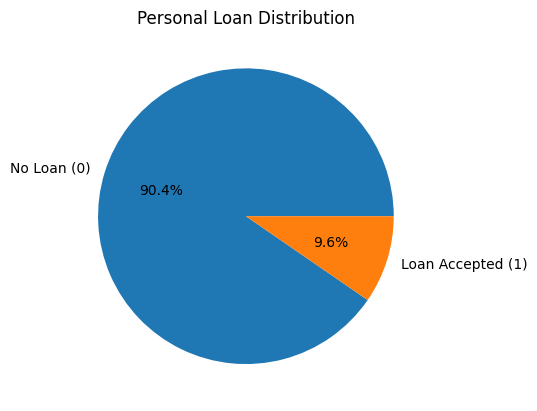

The target is imbalanced, so accuracy alone is not enough for evaluation.


In [9]:
print(df['Personal Loan'].value_counts())
print()
print("Percentages:")
print((df['Personal Loan'].value_counts(normalize=True) * 100).round(2))

counts = df['Personal Loan'].value_counts().sort_index()

plt.pie(counts.values, labels=['No Loan (0)', 'Loan Accepted (1)'], autopct='%1.1f%%')
plt.title("Personal Loan Distribution")
plt.show()

print("The target is imbalanced, so accuracy alone is not enough for evaluation.")

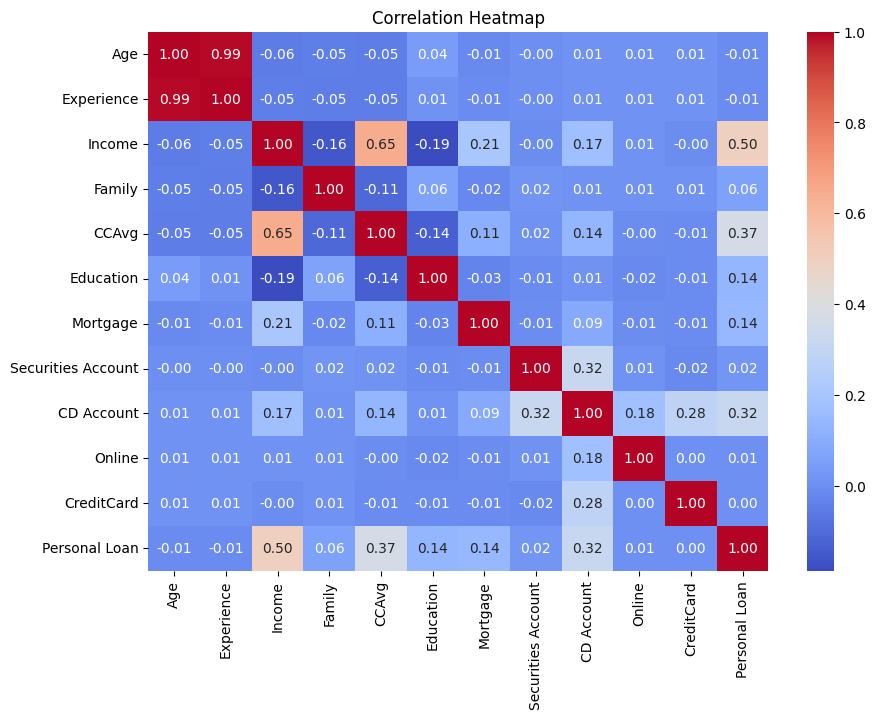

Age and Experience correlation: 0.9942


In [10]:
corr = df.drop(columns=['ID', 'ZIP Code']).corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

print("Age and Experience correlation:", round(df[['Age', 'Experience']].corr().iloc[0, 1], 4))

In [11]:
# ID is only a row number.
# ZIP Code should not be treated as a normal number.
# Experience has negative values and is almost the same as Age.

df_model = df.drop(columns=['ID', 'ZIP Code', 'Experience']).copy()

df_model.head()

,Age,Income,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,Personal Loan
0,25,49,4,1.6,1,0,1,0,0,0,0
1,45,34,3,1.5,1,0,1,0,0,0,0
2,39,11,1,1.0,1,0,0,0,0,0,0
3,35,100,1,2.7,2,0,0,0,0,0,0
4,35,45,4,1.0,2,0,0,0,0,1,0


In [12]:
X = df_model.drop(columns=['Personal Loan'])
y = df_model['Personal Loan']

print("Input features:")
print(list(X.columns))

print("X shape:", X.shape)
print("y shape:", y.shape)

Input features:
['Age', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
X shape: (5000, 10)
y shape: (5000,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape[0], "rows")
print("Test set:", X_test.shape[0], "rows")


print("Training target distribution:")
print(y_train.value_counts())


print("Test target distribution:")
print(y_test.value_counts())

Training set: 4000 rows
Test set: 1000 rows
Training target distribution:
Personal Loan
0    3616
1     384
Name: count, dtype: int64
Test target distribution:
Personal Loan
0    904
1     96
Name: count, dtype: int64


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [15]:
# K-means is used for exploration only.

cluster_features = ['Age', 'Income', 'CCAvg', 'Mortgage', 'Family']
X_cluster = df[cluster_features].copy()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

X_cluster.head()

,Age,Income,CCAvg,Mortgage,Family
0,25,49,1.6,0,4
1,45,34,1.5,0,3
2,39,11,1.0,0,1
3,35,100,2.7,0,1
4,35,45,1.0,0,4


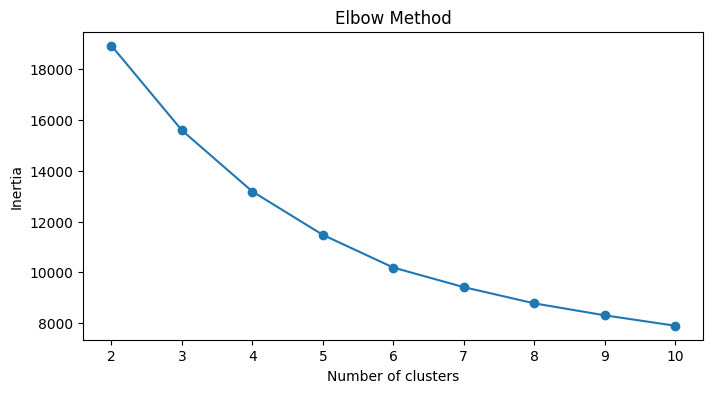

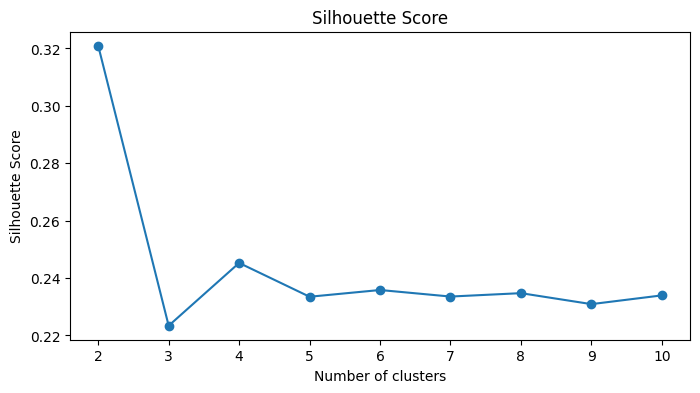

In [16]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

In [17]:
elbow_k = 6
silhouette_k = 2

print("Elbow method suggested k =", elbow_k)
print("Silhouette score suggested k =", silhouette_k)

best_k_cluster = silhouette_k

print("Final selected k =", best_k_cluster)

Elbow method suggested k = 6
Silhouette score suggested k = 2
Final selected k = 2


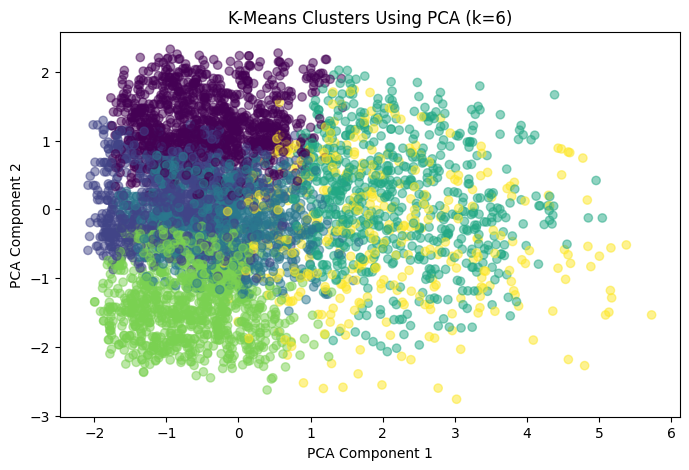

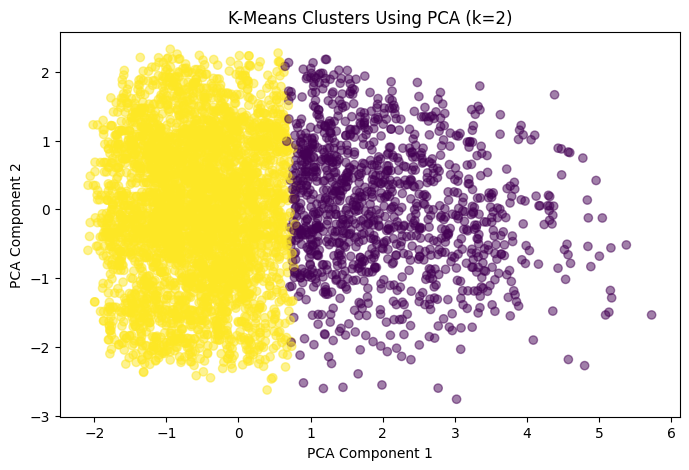

k=6 gives more clusters, but the clusters overlap more.
k=2 gives a clearer split and has the highest silhouette score.


In [18]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_6 = kmeans_6.fit_predict(X_cluster_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_6, cmap='viridis', alpha=0.5)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clusters Using PCA (k=6)')
plt.show()

kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2 = kmeans_2.fit_predict(X_cluster_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_2, cmap='viridis', alpha=0.5)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clusters Using PCA (k=2)')
plt.show()

print("k=6 gives more clusters, but the clusters overlap more.")
print("k=2 gives a clearer split and has the highest silhouette score.")

In [19]:
kmeans = KMeans(n_clusters=best_k_cluster, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

print("Final K-Means model trained with k =", best_k_cluster)
print(df_clustered['Cluster'].value_counts().sort_index())

Final K-Means model trained with k = 2
Cluster
0    1128
1    3872
Name: count, dtype: int64


In [20]:
cluster_profile = df_clustered.groupby('Cluster')[cluster_features + ['Personal Loan']].mean().round(2)
cluster_profile['Size'] = df_clustered.groupby('Cluster').size()

cluster_profile

,Age,Income,CCAvg,Mortgage,Family,Personal Loan,Size
Cluster,,,,,,,
0,44.11,139.38,4.19,109.11,1.89,0.36,1128
1,45.70,54.66,1.28,41.17,2.54,0.02,3872


In [21]:
print("Loan acceptance rate by cluster:")
print((df_clustered.groupby('Cluster')['Personal Loan'].mean() * 100).round(2))

Loan acceptance rate by cluster:
Cluster
0    35.90
1     1.94
Name: Personal Loan, dtype: float64


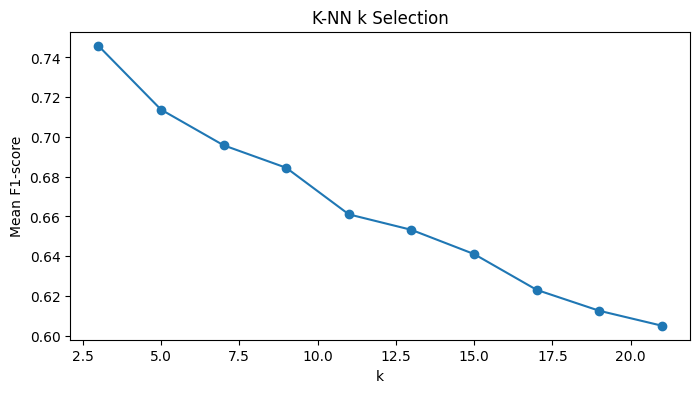

Best k: 3
Best mean F1-score: 0.7459


In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_values = range(3, 22, 2)
cv_f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='f1')
    cv_f1_scores.append(scores.mean())

best_k = list(k_values)[np.argmax(cv_f1_scores)]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), cv_f1_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Mean F1-score')
plt.title('K-NN k Selection')
plt.show()

print("Best k:", best_k)
print("Best mean F1-score:", round(max(cv_f1_scores), 4))


K-NN F1 score: 0.7976


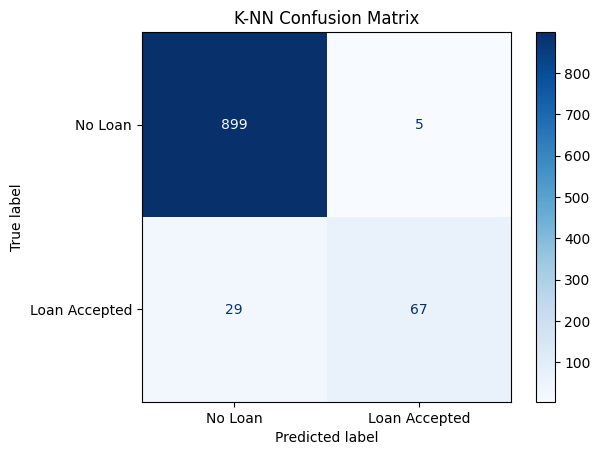

In [23]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
knn_f1 = round(f1_score(y_test, y_pred_knn, zero_division=0), 4)

print("K-NN F1 score:", knn_f1)

cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No Loan', 'Loan Accepted'])
disp_knn.plot(cmap='Blues')
plt.title('K-NN Confusion Matrix')
plt.show()


In [24]:
knn_accuracy = round(accuracy_score(y_test, y_pred_knn), 4)
knn_precision = round(precision_score(y_test, y_pred_knn, zero_division=0), 4)
knn_recall = round(recall_score(y_test, y_pred_knn, zero_division=0), 4)
knn_f1 = round(f1_score(y_test, y_pred_knn, zero_division=0), 4)

In [25]:
input_dim = X_train_scaled.shape[1]

ann_model = Sequential()
ann_model.add(Dense(32, activation='relu', input_dim=input_dim))
ann_model.add(Dense(16, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann_model.summary()


C:\Users\qaisb\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │             352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
ann_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8970 - loss: 0.3355
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9417 - loss: 0.1596
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9575 - loss: 0.1175
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9655 - loss: 0.0987
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9695 - loss: 0.0870
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9737 - loss: 0.0795
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9745 - loss: 0.0736
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9760 - loss: 0.0701
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9768 - loss: 0.0668
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9778 - loss: 0.0638
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9803 - loss: 0.0624
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
ANN F1 score: 0.9167


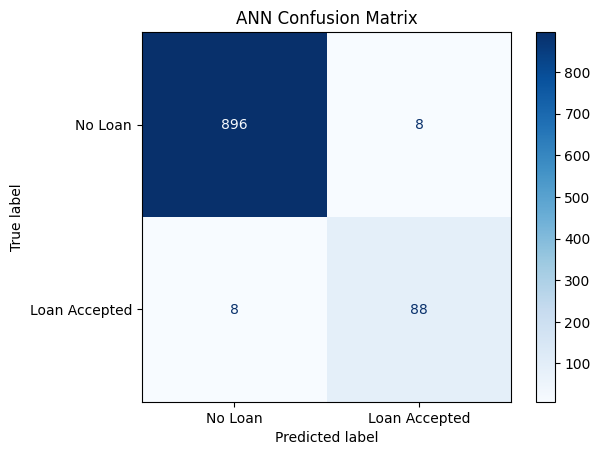

In [27]:
y_prob_ann = ann_model.predict(X_test_scaled)
y_pred_ann = (y_prob_ann > 0.5).astype(int).ravel()
ann_f1 = round(f1_score(y_test, y_pred_ann, zero_division=0), 4)

print("ANN F1 score:", ann_f1)

cm_ann = confusion_matrix(y_test, y_pred_ann)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=['No Loan', 'Loan Accepted'])
disp_ann.plot(cmap='Blues')
plt.title('ANN Confusion Matrix')
plt.show()

In [28]:
ann_accuracy = round(accuracy_score(y_test, y_pred_ann), 4)
ann_precision = round(precision_score(y_test, y_pred_ann, zero_division=0), 4)
ann_recall = round(recall_score(y_test, y_pred_ann, zero_division=0), 4)
ann_f1 = round(f1_score(y_test, y_pred_ann, zero_division=0), 4)

In [29]:
comparison = pd.DataFrame({
    'Accuracy': [knn_accuracy, ann_accuracy],
    'Precision': [knn_precision, ann_precision],
    'Recall': [knn_recall, ann_recall],
    'F1 Score': [knn_f1, ann_f1]}, index=['K-NN', 'ANN'])

comparison

,Accuracy,Precision,Recall,F1 Score
K-NN,0.966,0.9306,0.6979,0.7976
ANN,0.984,0.9167,0.9167,0.9167


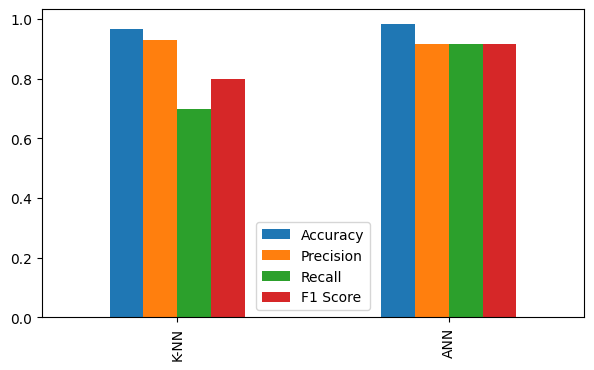

In [30]:
comparison.plot(kind='bar', figsize=(7, 4))
plt.show()
